In [54]:
import pandas as pd
df=pd.read_csv("World_Happiness_Report.csv")
df

,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption
0,Afghanistan,South Asia,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686
1,Afghanistan,South Asia,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035
2,Afghanistan,South Asia,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766
3,Afghanistan,South Asia,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109
4,Afghanistan,South Asia,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620
...,...,...,...,...,...,...,...,...,...,...
2194,Zimbabwe,Sub-Saharan Africa,2018,3.616480,7.783066,0.775388,52.625000,0.762675,-0.051219,0.844209
2195,Zimbabwe,Sub-Saharan Africa,2019,2.693523,7.697755,0.759162,53.099998,0.631908,-0.047464,0.830652
2196,Zimbabwe,Sub-Saharan Africa,2020,3.159802,7.596050,0.717243,53.575001,0.643303,0.006313,0.788523
2197,Zimbabwe,Sub-Saharan Africa,2021,3.154578,7.656878,0.685151,54.049999,0.667636,-0.075575,0.756945


In [56]:
import numpy as np  
import matplotlib.pyplot as plt   # for making charts
import seaborn as sns  

In [35]:
print(df.shape)

(2199, 10)


In [58]:
print(df.isnull().sum ())

Country Name                          0
Regional Indicator                  112
Year                                  0
Life Ladder                           0
Log GDP Per Capita                   20
Social Support                       13
Healthy Life Expectancy At Birth     54
Freedom To Make Life Choices         33
Generosity                           73
Perceptions Of Corruption           116
dtype: int64


In [60]:
# Find only the numeric columns (happiness score, GDP, etc.)
numeric_columns = df.select_dtypes(include=np.number).columns

# Fill any missing numbers with the median (middle value) of that column
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [62]:
print(df.dtypes)

Country Name                         object
Regional Indicator                   object
Year                                  int64
Life Ladder                         float64
Log GDP Per Capita                  float64
Social Support                      float64
Healthy Life Expectancy At Birth    float64
Freedom To Make Life Choices        float64
Generosity                          float64
Perceptions Of Corruption           float64
dtype: object


In [64]:
print(df.describe()) 

              Year  Life Ladder  Log GDP Per Capita  Social Support  \
count  2199.000000  2199.000000         2199.000000     2199.000000   
mean   2014.161437     5.479226            9.390759        0.810826   
std       4.718736     1.125529            1.148175        0.120609   
min    2005.000000     1.281271            5.526723        0.228217   
25%    2010.000000     4.646750            8.505131        0.747512   
50%    2014.000000     5.432437            9.498955        0.835535   
75%    2018.000000     6.309460           10.366237        0.904607   
max    2022.000000     8.018934           11.663788        0.987343   

       Healthy Life Expectancy At Birth  Freedom To Make Life Choices  \
count                       2199.000000                   2199.000000   
mean                          63.337690                      0.748187   
std                            6.821220                      0.139120   
min                            6.720000                      0.25753

Generosity                          0.803188
Life Ladder                        -0.017807
Year                               -0.076631
Log GDP Per Capita                 -0.338979
Freedom To Make Life Choices       -0.681836
Social Support                     -1.124570
Healthy Life Expectancy At Birth   -1.174758
Perceptions Of Corruption          -1.566034
dtype: float64


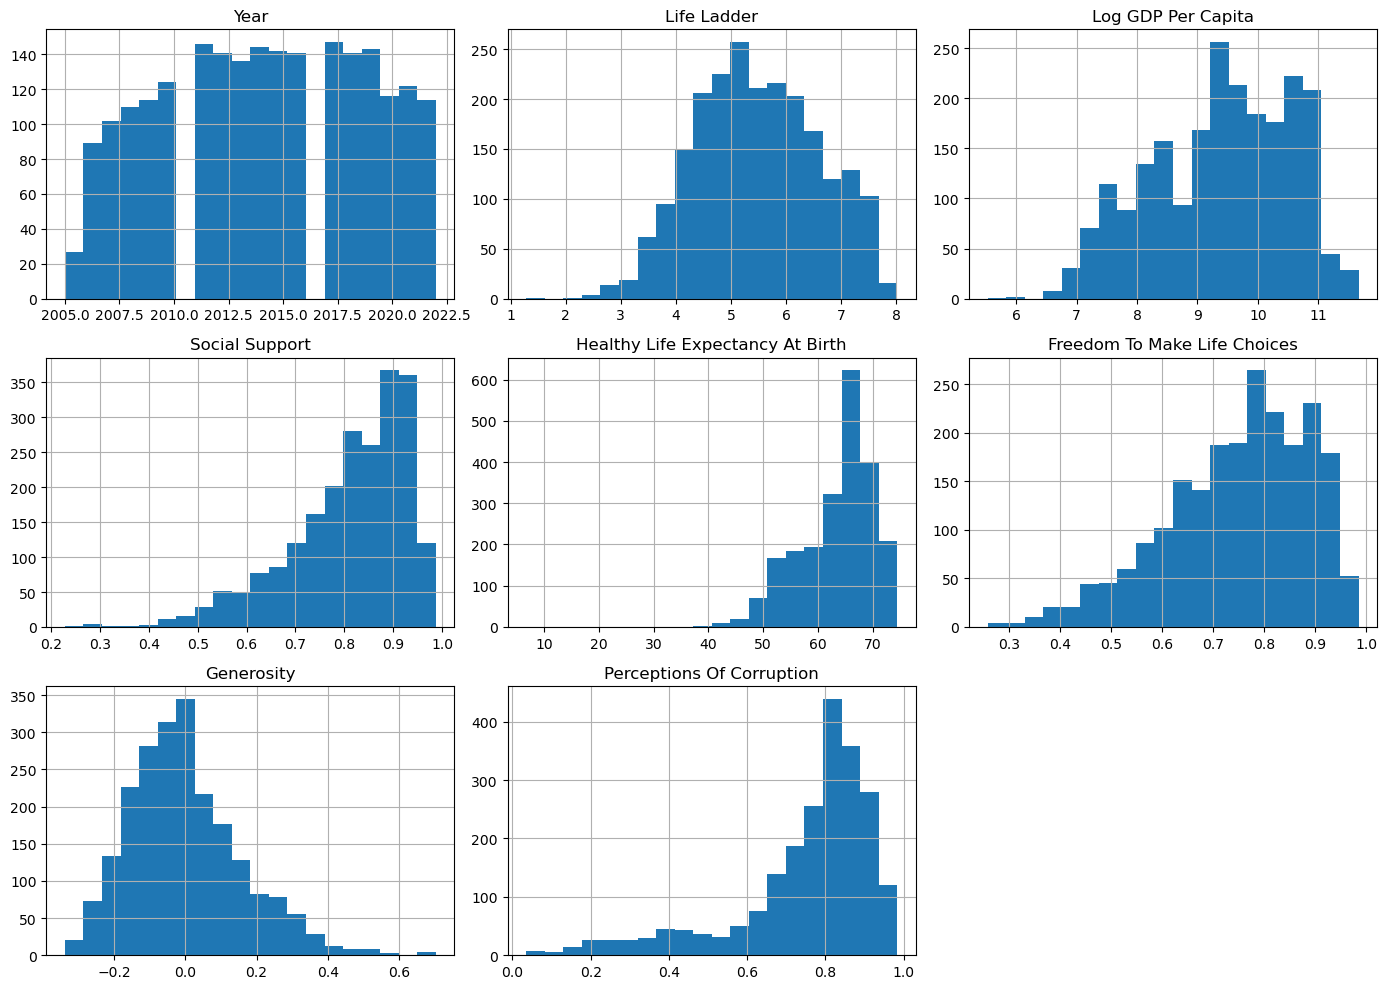

In [66]:
from scipy.stats import skew

numeric_columns = df.select_dtypes(include=np.number).columns

skewness = df[numeric_columns].apply(lambda x: skew(x.dropna()))
print(skewness.sort_values(ascending=False))
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show() 

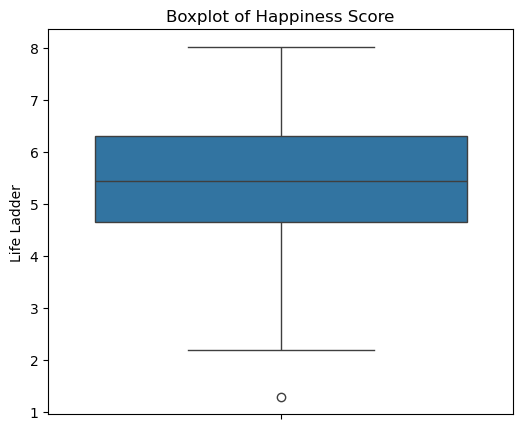

In [46]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['Life Ladder'])
plt.title("Boxplot of Happiness Score")
plt.show() 

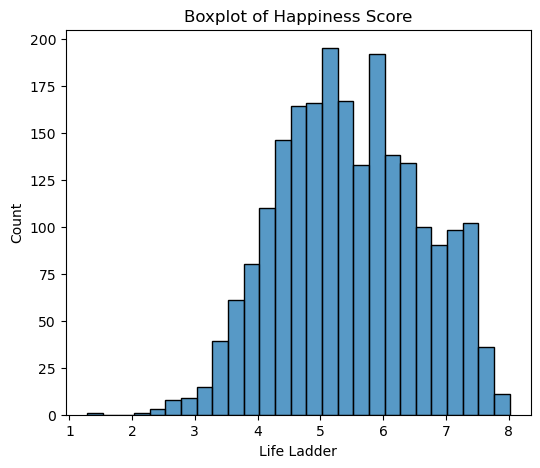

In [48]:
plt.figure(figsize=(6,5))
sns.histplot(df['Life Ladder'])
plt.title("Boxplot of Happiness Score")
plt.show() 

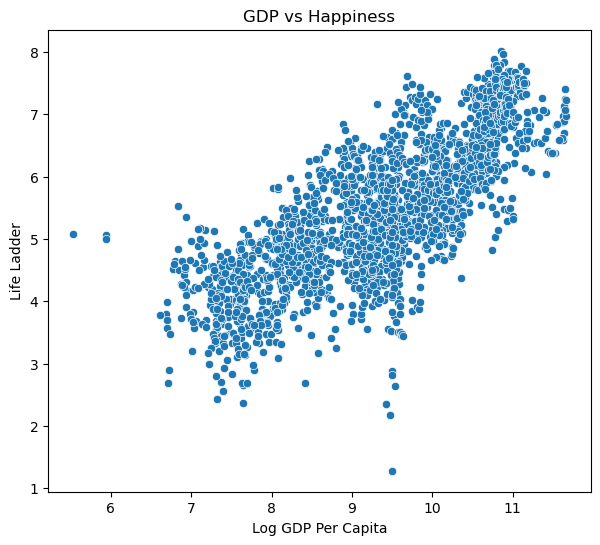

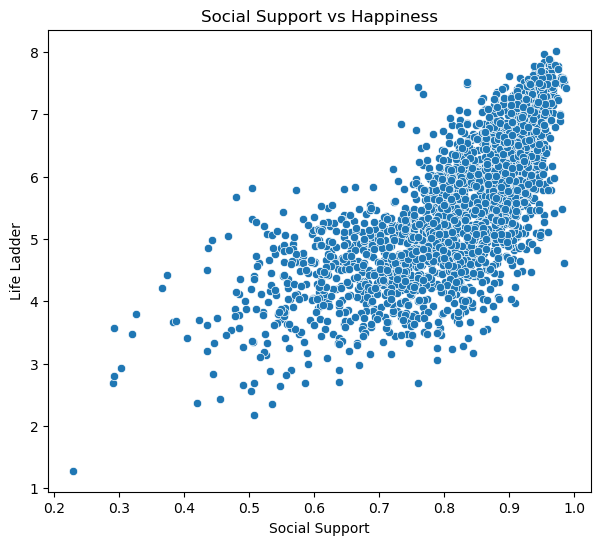

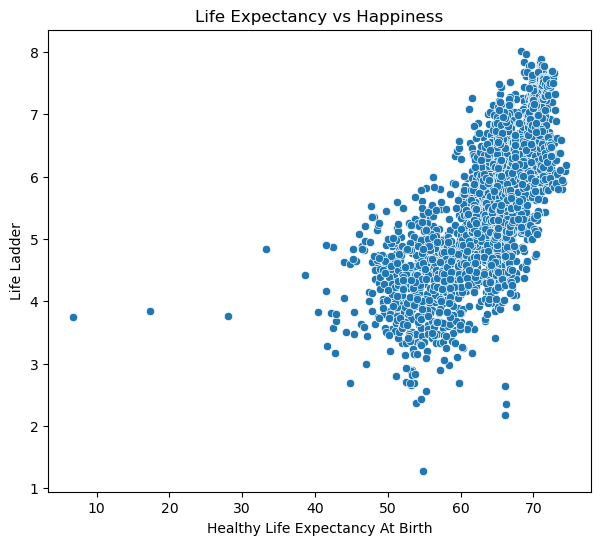

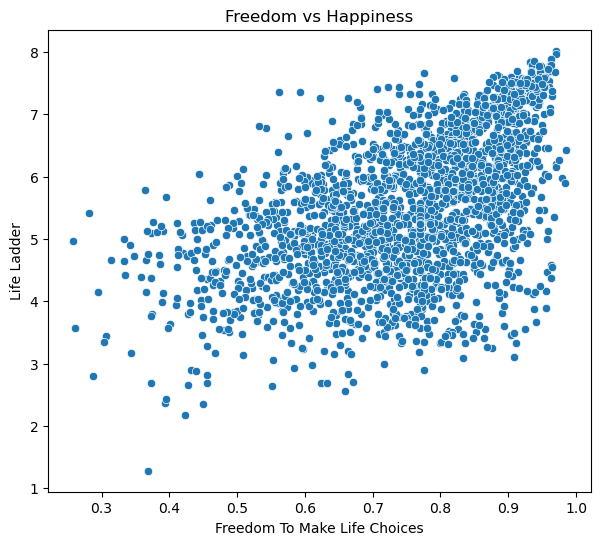

In [52]:
# Life Ladder is your happiness score (the target). Let's check it against each feature one by one.

plt.figure(figsize=(7,6))
sns.scatterplot(x='Log GDP Per Capita', y='Life Ladder', data=df)
plt.title("GDP vs Happiness")
plt.show()

plt.figure(figsize=(7,6))
sns.scatterplot(x='Social Support', y='Life Ladder', data=df)
plt.title("Social Support vs Happiness")
plt.show()

plt.figure(figsize=(7,6))
sns.scatterplot(x='Healthy Life Expectancy At Birth', y='Life Ladder', data=df)
plt.title("Life Expectancy vs Happiness")
plt.show()

plt.figure(figsize=(7,6))
sns.scatterplot(x='Freedom To Make Life Choices', y='Life Ladder', data=df)
plt.title("Freedom vs Happiness")
plt.show()

In [56]:
correlations_with_target = df[numeric_columns].corr()['Life Ladder'].sort_values(ascending=False)
print(correlations_with_target)

Life Ladder                         1.000000
Log GDP Per Capita                  0.778209
Social Support                      0.720074
Healthy Life Expectancy At Birth    0.710275
Freedom To Make Life Choices        0.532433
Generosity                          0.176243
Year                                0.045943
Perceptions Of Corruption          -0.420254
Name: Life Ladder, dtype: float64


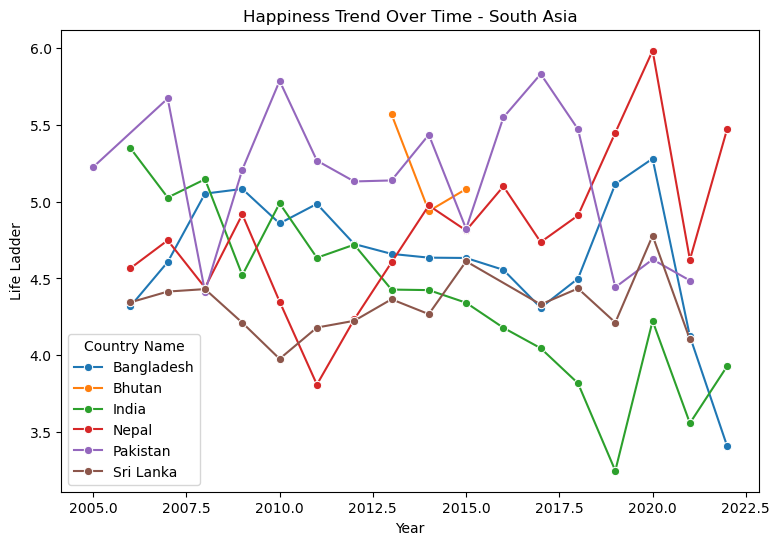

In [78]:
south_asia_data = df[df['Country Name'].isin(south_asia)]

plt.figure(figsize=(9,6))
sns.lineplot(x='Year', y='Life Ladder', hue='Country Name', data=south_asia_data, marker='o')
plt.title("Happiness Trend Over Time - South Asia")
plt.show()

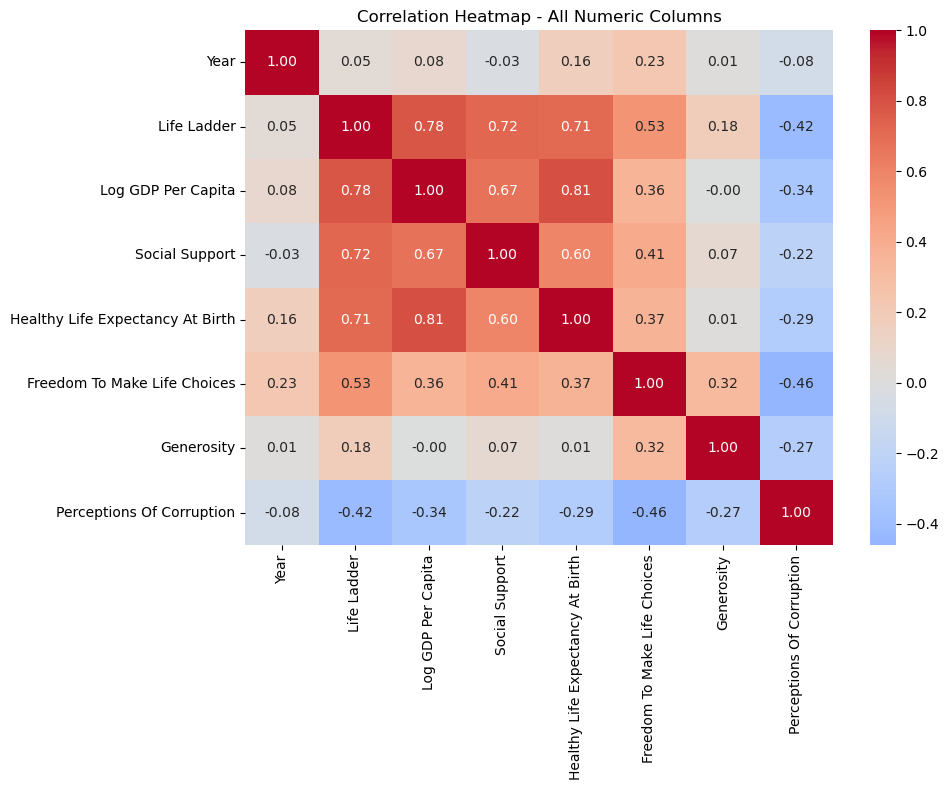

In [54]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,8))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - All Numeric Columns")
plt.tight_layout()
plt.show()

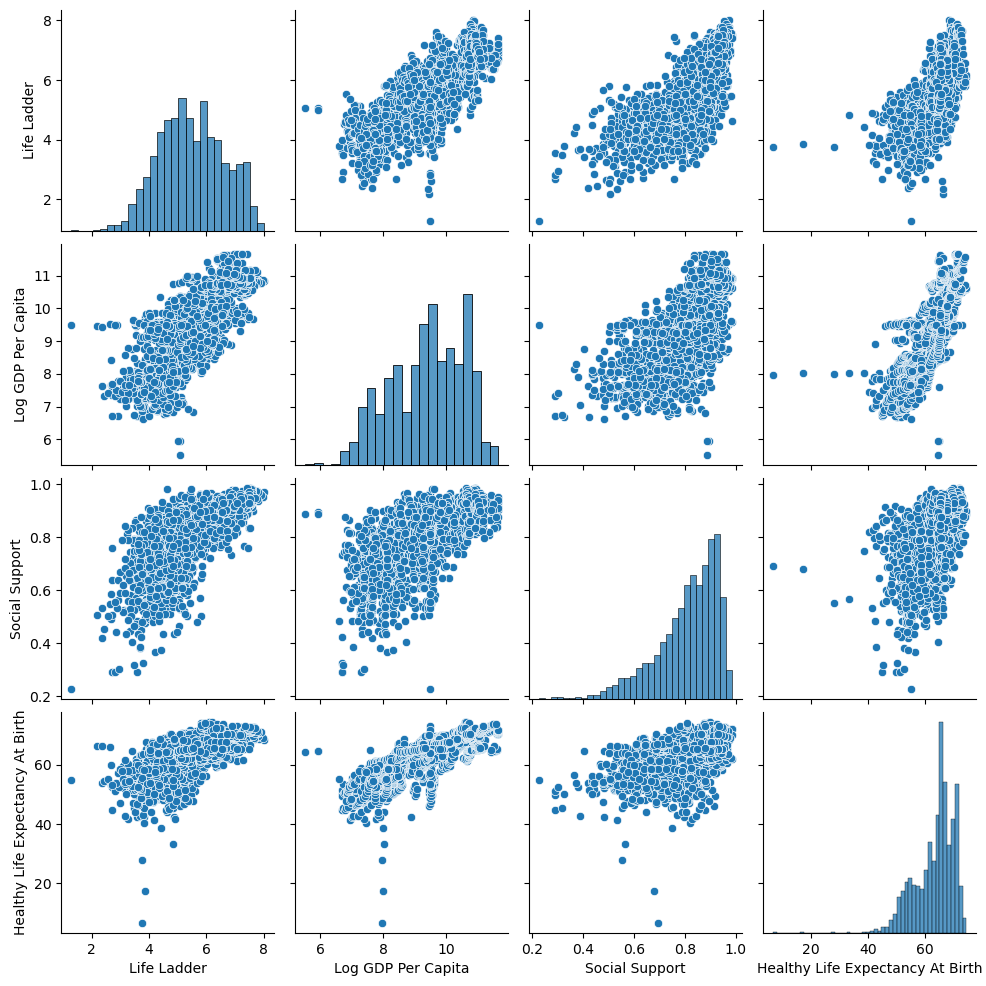

In [81]:
key_columns = ['Life Ladder', 'Log GDP Per Capita', 'Social Support', 'Healthy Life Expectancy At Birth']

sns.pairplot(df[key_columns])
plt.show()

development_index                   0.823835
Log GDP Per Capita                  0.778209
Social Support                      0.720074
Healthy Life Expectancy At Birth    0.710275
Freedom To Make Life Choices        0.532433
Generosity                          0.176243
Year                                0.045943
Perceptions Of Corruption          -0.420254
happiness_rank                     -0.948613
Name: Life Ladder, dtype: float64


C:\Users\ranja\AppData\Local\Temp\ipykernel_8456\1618637726.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_with_target.values, y=correlations_with_target.index, palette=colors)


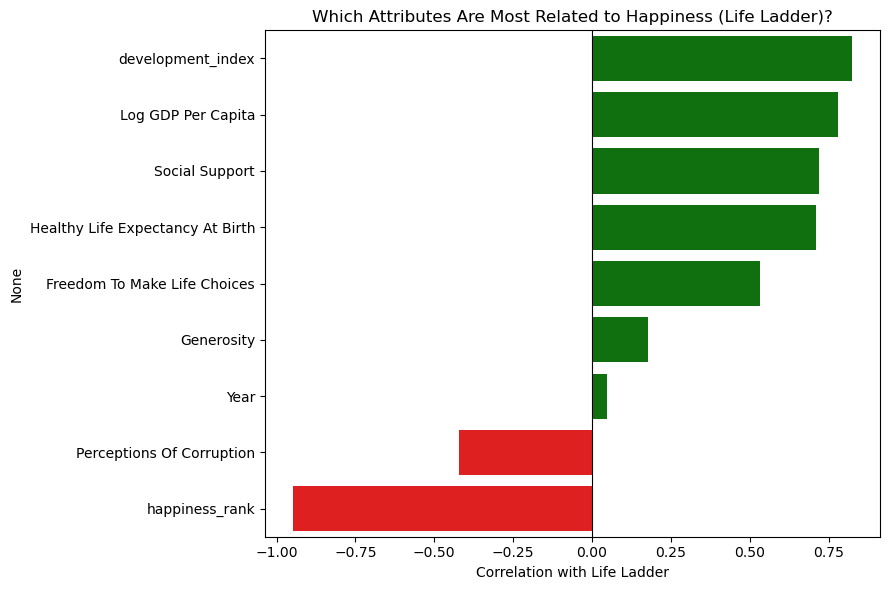

In [96]:
numeric_columns = df.select_dtypes(include=np.number).columns

# Correlation of every column with Life Ladder, sorted from strongest to weakest
correlations_with_target = df[numeric_columns].corr()['Life Ladder'].sort_values(ascending=False)

# Remove Life Ladder's correlation with itself (it's always 1.0, not useful)
correlations_with_target = correlations_with_target.drop('Life Ladder')

print(correlations_with_target)
plt.figure(figsize=(9,6))
colors = ['green' if val > 0 else 'red' for val in correlations_with_target.values]

sns.barplot(x=correlations_with_target.values, y=correlations_with_target.index, palette=colors)
plt.title("Which Attributes Are Most Related to Happiness (Life Ladder)?")
plt.xlabel("Correlation with Life Ladder")
plt.axvline(0, color='black', linewidth=0.8)  # a vertical line at 0 for reference
plt.tight_layout()
plt.show()

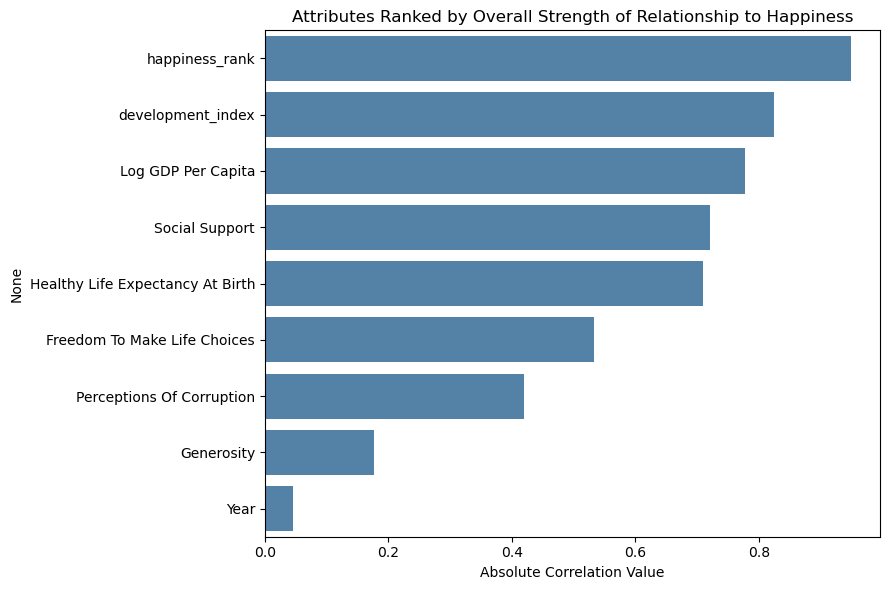

In [104]:
# Rank by strength (ignoring positive/negative direction)
correlations_by_strength = correlations_with_target.abs().sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=correlations_by_strength.values, y=correlations_by_strength.index, color='steelblue')
plt.title("Attributes Ranked by Overall Strength of Relationship to Happiness")
plt.xlabel("Absolute Correlation Value")
plt.tight_layout()
plt.show()

In [108]:
# Drop the leakage column and the redundant blended index (from earlier)
df_model_ready = df.drop(columns=['happiness_rank', 'development_index'])

numeric_columns = df_model_ready.select_dtypes(include=np.number).columns
target_column = 'Life Ladder'
feature_columns = [col for col in numeric_columns if col != target_column]

X = df_model_ready[feature_columns]
y = df_model_ready[target_column]

print("Using these features:", feature_columns)

Using these features: ['Year', 'Log GDP Per Capita', 'Social Support', 'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices', 'Generosity', 'Perceptions Of Corruption']


In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train rows:", len(X_train), "| Test rows:", len(X_test))

Train rows: 1759 | Test rows: 440


In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
}

In [88]:
from sklearn.metrics import mean_absolute_error, r2_score

results = {}
trained_models = {}

for name, model in models.items():
    # Linear Regression uses scaled data, tree models use original data
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    trained_models[name] = model

    print(f"{name}: MAE = {mae:.3f}, RMSE = {rmse:.3f}, R2 = {r2:.3f}")

# Put all results side by side, sorted by best RMSE first
results_df = pd.DataFrame(results).T.sort_values("RMSE")
print("\nModel Comparison:")
print(results_df)

# Pick the winner automatically
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"\nBest model: {best_model_name}")

Linear Regression: MAE = 0.443, RMSE = 0.580, R2 = 0.712
Random Forest: MAE = 0.339, RMSE = 0.461, R2 = 0.818
XGBoost: MAE = 0.375, RMSE = 0.499, R2 = 0.787

Model Comparison:
                        MAE      RMSE        R2
Random Forest      0.339426  0.461069  0.818039
XGBoost            0.375128  0.499429  0.786503
Linear Regression  0.442997  0.579621  0.712437

Best model: Random Forest


In [94]:
from sklearn.model_selection import cross_val_score

# Use the right version of X depending on which model won
if best_model_name == "Linear Regression":
    X_for_cv = scaler.fit_transform(X)   # scale the FULL X, not just X_train
else:
    X_for_cv = X

cv_scores = cross_val_score(best_model, X_for_cv, y, cv=5, scoring='r2')

print(f"\nCross-validation results for {best_model_name}:")
print("Individual fold scores:", cv_scores)
print(f"Average R2: {cv_scores.mean():.3f}")
print(f"Standard deviation: {cv_scores.std():.3f}")


Cross-validation results for Random Forest:
Individual fold scores: [0.78274084 0.6646096  0.70346881 0.69040667 0.74776334]
Average R2: 0.718
Standard deviation: 0.042


In [98]:
print(f"\nInterpretation:")
if cv_scores.std() < 0.05:
    print("Low variance across folds — this model's performance looks stable and trustworthy.")
else:
    print("Higher variance across folds — performance may depend on which rows are tested, worth noting as a limitation.")


Interpretation:
Low variance across folds — this model's performance looks stable and trustworthy.


In [100]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
print(results_df)

                        MAE      RMSE        R2
Random Forest      0.339426  0.461069  0.818039
XGBoost            0.375128  0.499429  0.786503
Linear Regression  0.442997  0.579621  0.712437


In [102]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)

# Feature importance only works for Random Forest / Gradient Boosting, not Linear Regression
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_columns)
    importance = importance.sort_values(ascending=False)
    print(importance)

Best model: Random Forest
Log GDP Per Capita                  0.649620
Healthy Life Expectancy At Birth    0.101776
Social Support                      0.096916
Freedom To Make Life Choices        0.062504
Generosity                          0.035354
Perceptions Of Corruption           0.033896
Year                                0.019934
dtype: float64


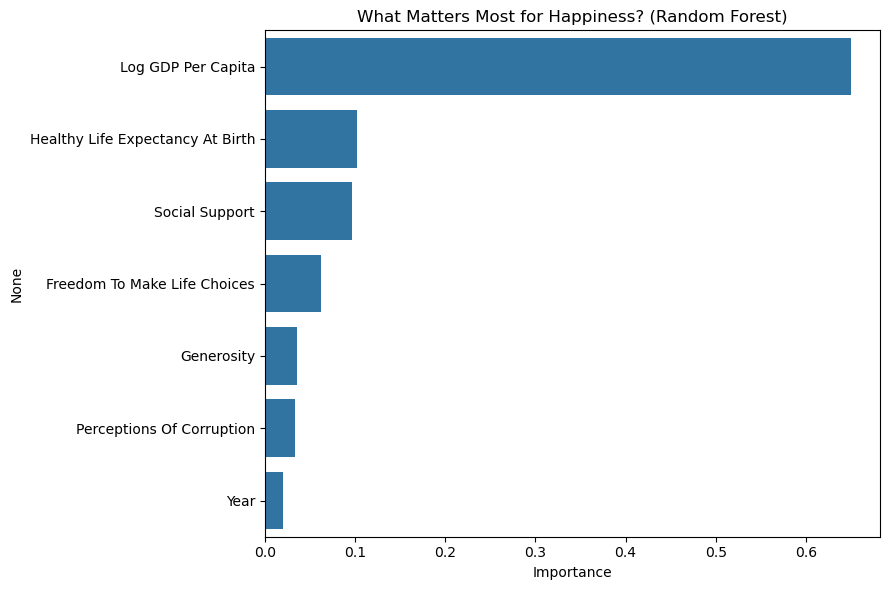

In [104]:
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(9,6))
    sns.barplot(x=importance.values, y=importance.index)
    plt.title(f"What Matters Most for Happiness? ({best_model_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [106]:
# Feature importance - only works for Random Forest/XGBoost, not Linear Regression
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_columns).sort_values(ascending=False)
    print(importance)

Log GDP Per Capita                  0.649620
Healthy Life Expectancy At Birth    0.101776
Social Support                      0.096916
Freedom To Make Life Choices        0.062504
Generosity                          0.035354
Perceptions Of Corruption           0.033896
Year                                0.019934
dtype: float64


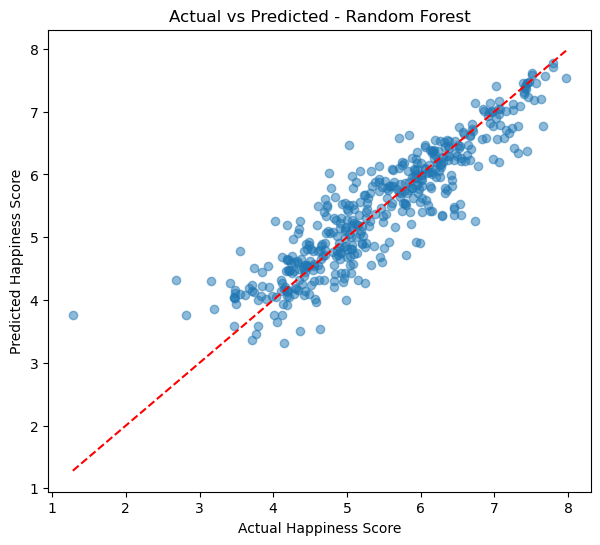

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, best_model.predict(X_test_scaled if best_model_name == "Linear Regression" else X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.show()

NaNs in df: 0
NaNs in X: 309
NaNs in X_train: 251
NaNs in X_test: 58
NaNs in X_train_scaled: 251
NaNs in X_test_scaled: 58
